# **Finding Outliers**


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [3]:
# Count industry responses
industry_counts = df['Industry'].value_counts(dropna=False)

print(industry_counts.head(10))

Industry
NaN                                           36579
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Name: count, dtype: int64


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 [Text(0, 0, 'nan'),
  Text(1, 0, 'Software Development'),
  Text(2, 0, 'Other:'),
  Text(3, 0, 'Fintech'),
  Text(4, 0, 'Internet, Telecomm or Information Services'),
  Text(5, 0, 'Banking/Financial Services'),
  Text(6, 0, 'Healthcare'),
  Text(7, 0, 'Manufacturing'),
  Text(8, 0, 'Retail and Consumer Services'),
  Text(9, 0, 'Government'),
  Text(10, 0, 'Media & Advertising Services'),
  Text(11, 0, 'Higher Education'),
  Text(12, 0, 'Transportation, or Supply Chain'),
  Text(13, 0, 'Computer Systems Design and Services'),
  Text(14, 0, 'Energy'),
  Text(15, 0, 'Insurance')])

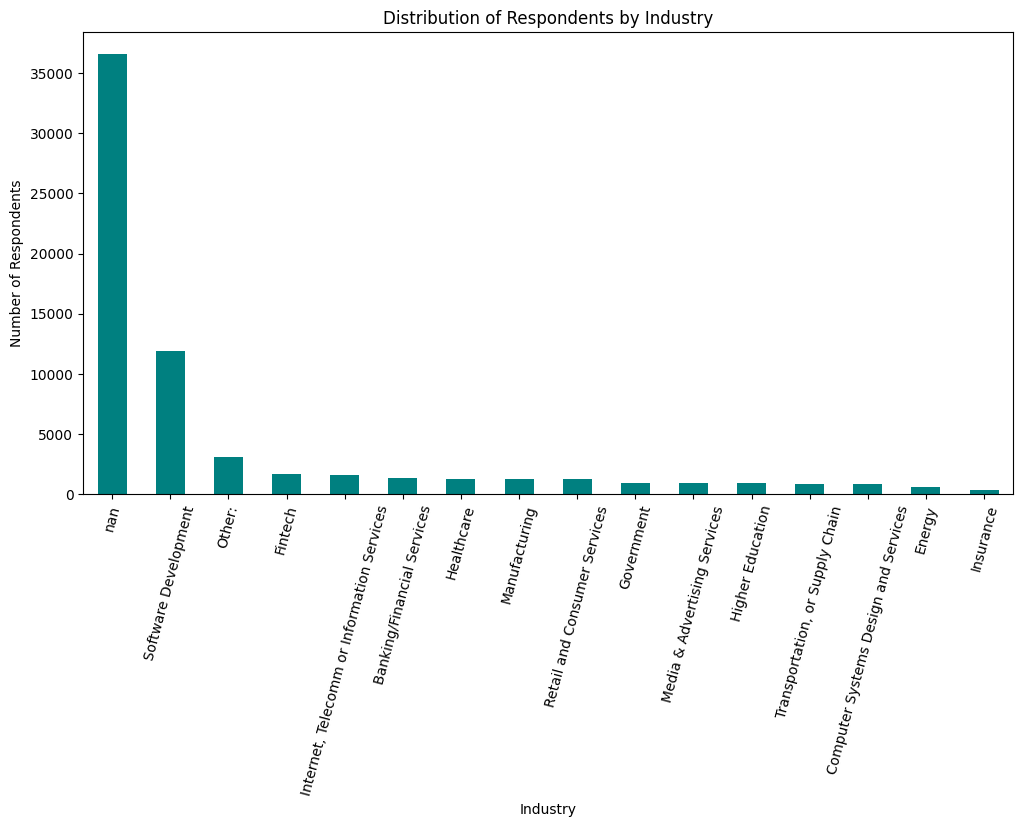

In [4]:

plt.figure(figsize=(12,6))
industry_counts.plot(kind='bar', color='teal')

plt.title("Distribution of Respondents by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=75)

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [5]:
comp = df['ConvertedCompYearly'].dropna()

# Basic statistics
mean_val = comp.mean()
median_val = comp.median()
std_val = comp.std()

print("Mean:", mean_val)
print("Median:", median_val)
print("Standard Deviation:", std_val)

Mean: 86155.28726264134
Median: 65000.0
Standard Deviation: 186756.97308629754


In [6]:
# Threshold for high outliers
threshold = mean_val + 3 * std_val

# Identify outliers
outliers = df[df['ConvertedCompYearly'] > threshold]

print("Outlier threshold:", threshold)
print("Number of outliers:", outliers.shape[0])
print(outliers[['ConvertedCompYearly','Employment','EdLevel','Country']].head())

Outlier threshold: 646426.206521534
Number of outliers: 89
      ConvertedCompYearly           Employment  \
529              650000.0  Employed, full-time   
828             1000000.0  Employed, full-time   
1932             945000.0  Employed, full-time   
2171             750000.0  Employed, full-time   
2187            2000000.0  Employed, full-time   

                                              EdLevel  \
529      Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
828   Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   
1932     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
2171     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
2187     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   

                       Country  
529   United States of America  
828   United States of America  
1932  United States of America  
2171  United States of America  
2187                     Gabon  


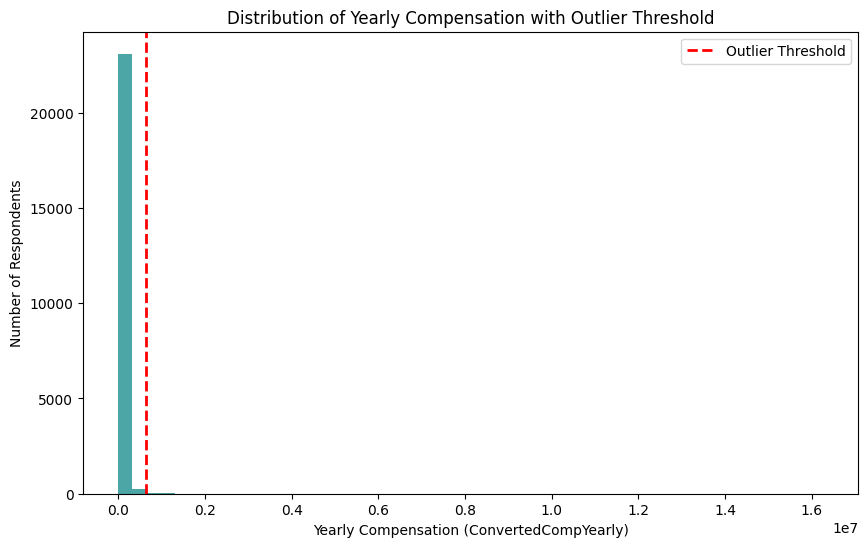

In [7]:

plt.figure(figsize=(10,6))
plt.hist(comp, bins=50, color='teal', alpha=0.7)
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label='Outlier Threshold')
plt.title("Distribution of Yearly Compensation with Outlier Threshold")
plt.xlabel("Yearly Compensation (ConvertedCompYearly)")
plt.ylabel("Number of Respondents")
plt.legend()

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [8]:
comp = df['ConvertedCompYearly'].dropna()

# Calculate Q1, Q3, and IQR
Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 32712.0
Q3: 107971.5
IQR: 75259.5


In [9]:
# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -80177.25
Upper Bound: 220860.75


In [10]:
# Identify outliers
outliers = comp[(comp < lower_bound) | (comp > upper_bound)]

print("Number of outliers:", outliers.shape[0])
print(outliers.head())

Number of outliers: 978
428    230000.0
456    300000.0
461    254425.0
529    650000.0
545    400000.0
Name: ConvertedCompYearly, dtype: float64


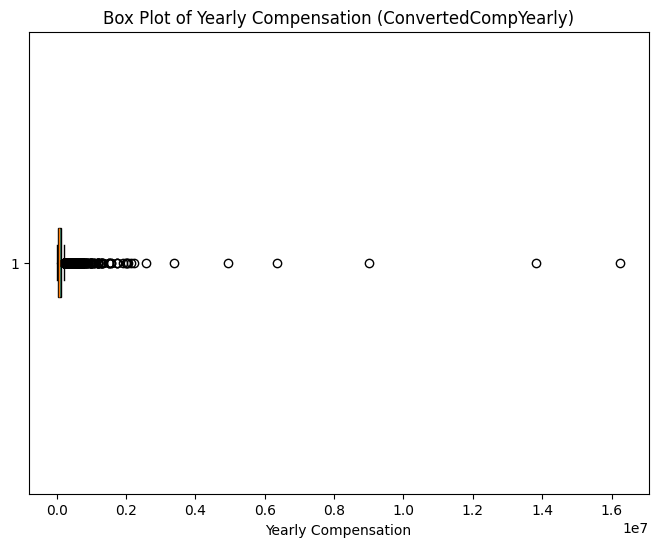

In [11]:

plt.figure(figsize=(8,6))
plt.boxplot(comp, vert=False, patch_artist=True, boxprops=dict(facecolor='teal'))
plt.title("Box Plot of Yearly Compensation (ConvertedCompYearly)")
plt.xlabel("Yearly Compensation")
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [16]:
# Exclude rows outside bounds
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & 
                    (df['ConvertedCompYearly'] <= upper_bound)]

In [17]:
print("Original dataset size:", df.shape)
print("New dataset size (without outliers):", df_no_outliers.shape)

Original dataset size: (65437, 114)
New dataset size (without outliers): (22457, 114)


In [15]:
print("Original compensation range:", comp.min(), "-", comp.max())
print("New compensation range:", df_no_outliers['ConvertedCompYearly'].min(), "-", df_no_outliers['ConvertedCompYearly'].max())

Original compensation range: 1.0 - 16256603.0
New compensation range: 1.0 - 220207.0


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [18]:
# Example mapping (adjust based on your dataset’s Age categories)
age_map = {
    'Under 18 years': 17,
    '18-24 years': 21,
    '25-34 years': 29,
    '35-44 years': 39,
    '45-54 years': 49,
    '55-64 years': 59,
    '65 years or older': 70
}

# Apply mapping
df['AgeNum'] = df['Age'].map(age_map)

In [19]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Focus on Age correlations
age_corr = corr_matrix['AgeNum'].sort_values(ascending=False)
print(age_corr)

ResponseId            NaN
CompTotal             NaN
WorkExp               NaN
JobSatPoints_1        NaN
JobSatPoints_4        NaN
JobSatPoints_5        NaN
JobSatPoints_6        NaN
JobSatPoints_7        NaN
JobSatPoints_8        NaN
JobSatPoints_9        NaN
JobSatPoints_10       NaN
JobSatPoints_11       NaN
ConvertedCompYearly   NaN
JobSat                NaN
AgeNum                NaN
Name: AgeNum, dtype: float64


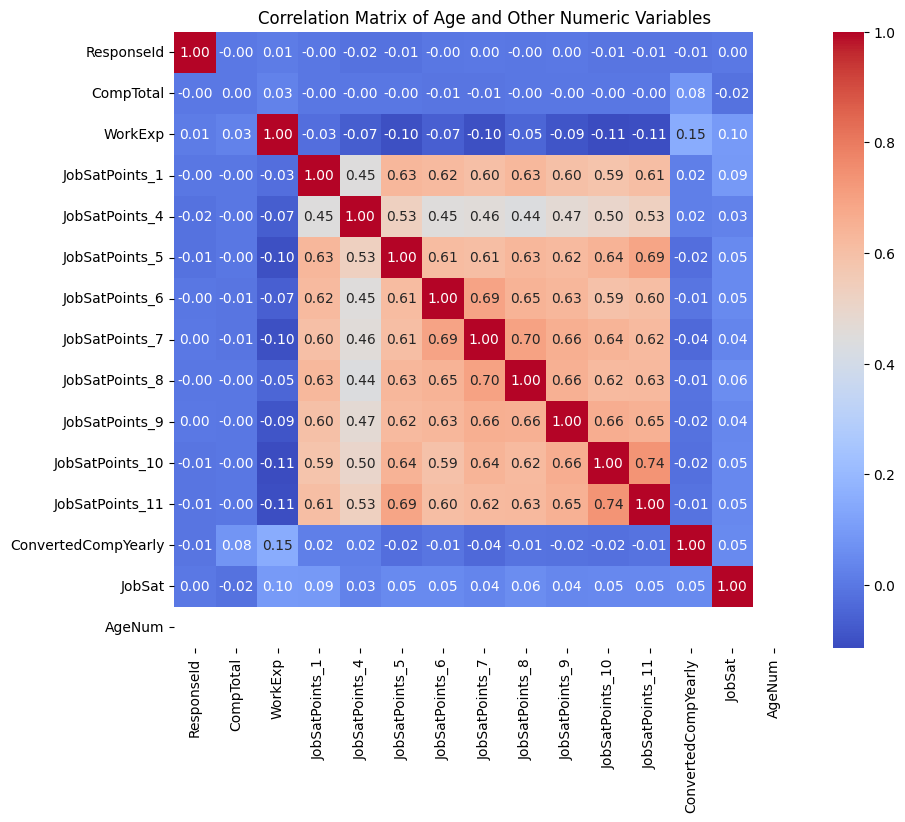

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

plt.title("Correlation Matrix of Age and Other Numeric Variables")
plt.show()

<h3> Summary </h3>


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>
